In [27]:
# ── Cell 1: Install Dependencies ─────────────────────────────────────────────
!pip install -q soundfile librosa tensorboard matplotlib tqdm

In [28]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import os, glob, json, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import soundfile as sf
import librosa
import librosa.display
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

matplotlib.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


In [29]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

# ── CELL 3: CONFIGURATION ─────────────────────────────────────────────────────
class Config:
    # ── Corrected Explicit Paths ──────────────────────────────────────────────
    DATA_DIR       = '/kaggle/input/datasets/siddhanta98/cadence-dataset/spectrograms/train'
    TEST_DATA_DIR  = '/kaggle/input/datasets/siddhanta98/cadence-dataset/spectrograms/test'
    OUTPUT_DIR     = '/kaggle/working'
    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    HIFIGAN_CKPT   = '/kaggle/input/hifigan/hifigan_v1.pth'  # optional

    # ── Genres (6 classes) ─────────────────────────────────────────────────────
    GENRES        = ['bhajan', 'deuda', 'lok_dohori', 'newari', 'tamang_selo', 'tharu']
    NUM_CLASSES   = len(GENRES)
    GENRE_EMB_DIM = 32

    # ── Spectrogram shape (diagram: 1 × 128 × 1292) ───────────────────────────
    MEL_CHANNELS = 128
    MEL_TIME     = 1292

    # ── VAE Architecture ───────────────────────────────────────────────────────
    LATENT_DIM   = 256
    POOL_H, POOL_W = 4, 40

    # ── Training ───────────────────────────────────────────────────────────────
    BATCH_SIZE    = 4       # keep low (T4/P100 memory)
    EPOCHS        = 50
    LR            = 1e-4
    WEIGHT_DECAY  = 1e-5
    CLIP_GRAD     = 1.0
    VAL_SPLIT     = 0.10    # 10% of training pool for validation

    # β warm-up: linearly ramp from BETA_START → BETA_END over WARMUP_EPOCHS
    BETA_START    = 0.0
    BETA_END      = 0.001
    WARMUP_EPOCHS = 10

    # Checkpointing
    SAVE_EVERY    = 5       # save a periodic checkpoint every N epochs

    # ── Audio ──────────────────────────────────────────────────────────────────
    SAMPLE_RATE  = 22050
    HOP_LENGTH   = 256
    N_FFT        = 1024
    GRIFFIN_ITER = 64       # Griffin-Lim iterations

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


config = Config()
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.OUTPUT_DIR,     exist_ok=True)

# Global mappings
genre_to_idx = {g: i for i, g in enumerate(config.GENRES)}
idx_to_genre = {i: g for g, i in genre_to_idx.items()}

print(f'Device  : {config.DEVICE}')
print(f'Genres  : {config.GENRES}')
print(f'Mel dim : {config.MEL_CHANNELS} × {config.MEL_TIME}')
print(f'Latent  : {config.LATENT_DIM}\n')

Device  : cuda
Genres  : ['bhajan', 'deuda', 'lok_dohori', 'newari', 'tamang_selo', 'tharu']
Mel dim : 128 × 1292
Latent  : 256



In [30]:
class MelSpectrogramDataset(Dataset):
    """
    Loads saved mel-spectrogram .npy arrays from
        <data_dir>/<genre>/*.npy

    Returns (mel_tensor: (1, MEL_CHANNELS, MEL_TIME), label: LongTensor)
    """

    def __init__(self, data_dir, genres, mapping, mel_ch=128, mel_t=1292):
        self.mel_ch = mel_ch
        self.mel_t  = mel_t
        self.files, self.labels = [], []

        for g in genres:
            folder = os.path.join(data_dir, g)
            if not os.path.isdir(folder):
                print(f'[WARN] Missing genre folder: {folder}')
                continue
            npy_files = sorted(glob.glob(os.path.join(folder, '*.npy')))
            self.files.extend(npy_files)
            self.labels.extend([mapping[g]] * len(npy_files))

        if not self.files:
            raise FileNotFoundError(f'No .npy files found in path: {data_dir}')

        # Per-genre stats calculation
        genre_counts = {}
        for lbl in self.labels:
            g_name = idx_to_genre[lbl]
            genre_counts[g_name] = genre_counts.get(g_name, 0) + 1
        print(f'Loaded Dataset from [{data_dir}]: {len(self.files)} files | {genre_counts}')

    def __len__(self):
        return len(self.files)

    def _pad_or_crop(self, mel):
        c, t = mel.shape
        # Frequency axis
        if c < self.mel_ch:
            mel = np.pad(mel, ((0, self.mel_ch - c), (0, 0)))
        else:
            mel = mel[:self.mel_ch]
        # Time axis
        if t < self.mel_t:
            mel = np.pad(mel, ((0, 0), (0, self.mel_t - t)))
        else:
            mel = mel[:, :self.mel_t]
        return mel

    def __getitem__(self, idx):
        mel   = np.load(self.files[idx]).astype(np.float32)   # (C, T)
        mel   = self._pad_or_crop(mel)
        mu, sigma = mel.mean(), mel.std() + 1e-8
        mel   = np.clip((mel - mu) / sigma, -4.0, 4.0) / 4.0  # → [-1, 1]
        tensor = torch.from_numpy(mel).unsqueeze(0)            # (1, C, T)
        label  = torch.tensor(self.labels[idx], dtype=torch.long)
        return tensor, label


# ── 1. Load & Split Training/Validation Pool ──────────────────────────────────
print("--- Initializing Data Splits ---")
train_val_dataset = MelSpectrogramDataset(
    config.DATA_DIR, config.GENRES, genre_to_idx,
    config.MEL_CHANNELS, config.MEL_TIME
)

n_val   = max(1, int(len(train_val_dataset) * config.VAL_SPLIT))
n_train = len(train_val_dataset) - n_val

train_set, val_set = random_split(
    train_val_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# ── 2. Load Independent Test Set ──────────────────────────────────────────────
test_set = MelSpectrogramDataset(
    config.TEST_DATA_DIR, config.GENRES, genre_to_idx,
    config.MEL_CHANNELS, config.MEL_TIME
)

# ── 3. Instantiate Phase DataLoaders (num_workers=0 fixes multi-processing bug) 
train_loader = DataLoader(train_set, batch_size=config.BATCH_SIZE,
                          shuffle=True,  drop_last=True,
                          num_workers=0, pin_memory=True)

val_loader   = DataLoader(val_set,  batch_size=config.BATCH_SIZE,
                          shuffle=False, drop_last=False,
                          num_workers=0, pin_memory=True)

test_loader  = DataLoader(test_set, batch_size=config.BATCH_SIZE,
                          shuffle=False, drop_last=False,
                          num_workers=0, pin_memory=True)

print(f'\n[SUCCESS] Splits allocated.')
print(f'  Train Batches : {len(train_loader)} ({len(train_set)} samples)')
print(f'  Val Batches   : {len(val_loader)} ({len(val_set)} samples)')
print(f'  Test Batches  : {len(test_loader)} ({len(test_set)} samples)')

# ── 4. Quick sanity check on the Test Loader ─────────────────────────────────
sample_mel, sample_lbl = next(iter(test_loader))
print(f'\n--- Test Loader Verification ---')
print(f'Batch shape : {sample_mel.shape}   dtype={sample_mel.dtype}')
print(f'Label shape : {sample_lbl.shape}   values={sample_lbl.tolist()}')
print(f'Mel range   : [{sample_mel.min():.3f}, {sample_mel.max():.3f}]')

--- Initializing Data Splits ---
Loaded Dataset from [/kaggle/input/datasets/siddhanta98/cadence-dataset/spectrograms/train]: 2903 files | {'bhajan': 413, 'deuda': 528, 'lok_dohori': 474, 'newari': 420, 'tamang_selo': 533, 'tharu': 535}
Loaded Dataset from [/kaggle/input/datasets/siddhanta98/cadence-dataset/spectrograms/test]: 810 files | {'bhajan': 166, 'deuda': 141, 'lok_dohori': 124, 'newari': 115, 'tamang_selo': 154, 'tharu': 110}

[SUCCESS] Splits allocated.
  Train Batches : 653 (2613 samples)
  Val Batches   : 73 (290 samples)
  Test Batches  : 203 (810 samples)

--- Test Loader Verification ---
Batch shape : torch.Size([4, 1, 128, 1292])   dtype=torch.float32
Label shape : torch.Size([4])   values=[0, 0, 0, 0]
Mel range   : [-0.993, 0.721]


In [31]:
# ── Cell 5: VAE Architecture (Phase 1 — exact diagram match) ─────────────────
#
#  Encoder (CNN):   Input(1×128×1292)
#                   → Conv(32) → BN → ReLU
#                   → Conv(64) → BN → ReLU
#                   → Conv(128)→ BN → ReLU
#                   → Conv(256)→ BN → ReLU
#                   → AdaptiveAvgPool(4×40)
#                   → Linear → μ  (256-d)
#                   → Linear → log σ²  (256-d)
#                   Genre embedding concatenated before the linear heads.
#
#  Reparameterise:  z = μ + exp(0.5 · log σ²) · ε,  ε ~ N(0,I)
#
#  Decoder (CNN):   z || genre_emb  → Linear
#                   → Reshape(256×4×40)
#                   → TransposedConv(128) → BN → ReLU
#                   → TransposedConv(64)  → BN → ReLU
#                   → TransposedConv(32)  → BN → ReLU
#                   → TransposedConv(1)   → Tanh
#                   → Bilinear resize to (128×1292)
# ─────────────────────────────────────────────────────────────────────────────

class ConditionalEncoder(nn.Module):
    """
    CNN Encoder that maps a mel-spectrogram (B, 1, MEL_CH, MEL_T)
    to a pair (μ, log σ²) each of shape (B, latent_dim).
    Genre label is embedded and concatenated before the linear heads.
    """
    def __init__(self, latent_dim, num_classes, emb_dim,
                 pool_h=4, pool_w=40):
        super().__init__()
        self.genre_emb = nn.Embedding(num_classes, emb_dim)

        # Four stride-2 convolutions matching the diagram boxes
        self.conv = nn.Sequential(
            # (B, 1,   128, T) → (B, 32,  64, T/2)
            nn.Conv2d(1,   32,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            # (B, 32,  64, T/2) → (B, 64,  32, T/4)
            nn.Conv2d(32,  64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            # (B, 64,  32, T/4) → (B, 128, 16, T/8)
            nn.Conv2d(64,  128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            # (B, 128, 16, T/8) → (B, 256,  8, T/16)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        # Pool to a fixed spatial size regardless of input length
        self.pool  = nn.AdaptiveAvgPool2d((pool_h, pool_w))
        flat_dim   = 256 * pool_h * pool_w          # 40 960

        self.fc_mu     = nn.Linear(flat_dim + emb_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim + emb_dim, latent_dim)

    def forward(self, x, labels):
        x  = self.conv(x)
        x  = self.pool(x)                     # (B, 256, pool_h, pool_w)
        x  = x.flatten(start_dim=1)           # (B, flat_dim)
        c  = self.genre_emb(labels)           # (B, emb_dim)
        xc = torch.cat([x, c], dim=1)
        return self.fc_mu(xc), self.fc_logvar(xc)


class ConditionalDecoder(nn.Module):
    """
    CNN Decoder that maps z (B, latent_dim) + genre label
    → reconstructed mel (B, 1, MEL_CH, MEL_T).
    """
    def __init__(self, latent_dim, num_classes, emb_dim,
                 mel_ch=128, mel_t=1292,
                 pool_h=4, pool_w=40):
        super().__init__()
        self.mel_ch = mel_ch
        self.mel_t  = mel_t
        self.pool_h = pool_h
        self.pool_w = pool_w

        self.genre_emb = nn.Embedding(num_classes, emb_dim)
        self.fc        = nn.Linear(latent_dim + emb_dim, 256 * pool_h * pool_w)

        self.deconv = nn.Sequential(
            # (B, 256, 4, 40) → (B, 128, 8,  80)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            # (B, 128, 8,  80) → (B, 64, 16, 160)
            nn.ConvTranspose2d(128, 64,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            # (B, 64, 16, 160) → (B, 32, 32, 320)
            nn.ConvTranspose2d(64,  32,  kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            # (B, 32, 32, 320) → (B,  1, 64, 640)
            nn.ConvTranspose2d(32,   1,  kernel_size=4, stride=2, padding=1),
            nn.Tanh(),     # output bounded to [-1, 1] matching normalised input
        )

    def forward(self, z, labels):
        c  = self.genre_emb(labels)            # (B, emb_dim)
        zc = torch.cat([z, c], dim=1)
        x  = self.fc(zc).view(-1, 256, self.pool_h, self.pool_w)
        x  = self.deconv(x)                    # (B, 1, 64, 640) approx.
        # Bilinear resize to exact target shape (diagram: 128 × 1292)
        x  = F.interpolate(x, size=(self.mel_ch, self.mel_t),
                           mode='bilinear', align_corners=False)
        return x


class CadenceCVAE(nn.Module):
    """
    Conditional Variational Autoencoder.
    Implements both Phase-1 (training) and Phase-2 (generation) from the diagram.
    """
    def __init__(self, latent_dim, num_classes, emb_dim,
                 mel_ch=128, mel_t=1292):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = ConditionalEncoder(latent_dim, num_classes, emb_dim)
        self.decoder = ConditionalDecoder(latent_dim, num_classes, emb_dim,
                                          mel_ch, mel_t)

    # ── Reparameterisation Trick (diagram box 4) ──────────────────────────────
    @staticmethod
    def reparameterize(mu, logvar):
        """z = μ + exp(0.5 · log σ²) · ε,   ε ~ N(0, I)"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # ── Phase-1 forward ───────────────────────────────────────────────────────
    def forward(self, x, labels):
        mu, logvar = self.encoder(x, labels)
        z          = self.reparameterize(mu, logvar)
        recon_x    = self.decoder(z, labels)
        return recon_x, mu, logvar

    # ── Phase-2 generation (diagram bottom panel) ─────────────────────────────
    @torch.no_grad()
    def generate(self, labels, z=None, temperature=1.0):
        """
        Sample z from N(0, temperature²·I) (or supply a custom z),
        then decode conditioned on `labels`.
        Returns synthesised mel: (B, 1, MEL_CH, MEL_T).
        """
        if z is None:
            z = torch.randn(len(labels), self.latent_dim,
                            device=labels.device) * temperature
        return self.decoder(z, labels)


# ── Instantiate ───────────────────────────────────────────────────────────────
cvae = CadenceCVAE(
    latent_dim  = config.LATENT_DIM,
    num_classes = config.NUM_CLASSES,
    emb_dim     = config.GENRE_EMB_DIM,
    mel_ch      = config.MEL_CHANNELS,
    mel_t       = config.MEL_TIME,
).to(config.DEVICE)

total_params = sum(p.numel() for p in cvae.parameters())
enc_params   = sum(p.numel() for p in cvae.encoder.parameters())
dec_params   = sum(p.numel() for p in cvae.decoder.parameters())
print(f'CVAE total parameters : {total_params:,}')
print(f'  Encoder             : {enc_params:,}')
print(f'  Decoder             : {dec_params:,}')

# ── Quick forward-pass smoke test ─────────────────────────────────────────────
with torch.no_grad():
    _x   = torch.randn(2, 1, config.MEL_CHANNELS, config.MEL_TIME).to(config.DEVICE)
    _lbl = torch.tensor([0, 1], dtype=torch.long).to(config.DEVICE)
    _recon, _mu, _lv = cvae(_x, _lbl)
print(f'Encoder μ shape  : {_mu.shape}')     # (2, 256)
print(f'Decoder out shape: {_recon.shape}')  # (2, 1, 128, 1292)

CVAE total parameters : 34,205,633
  Encoder             : 21,678,688
  Decoder             : 12,526,945
Encoder μ shape  : torch.Size([2, 256])
Decoder out shape: torch.Size([2, 1, 128, 1292])


In [32]:
# ── Cell 6: Loss Function (VAE Loss = MSE + β·KL) ────────────────────────────
#
#  Total Loss  = Reconstruction Loss  +  β × KL Divergence
#
#  Reconstruction: MSE(reconstructed_mel, ground_truth_mel)   ← diagram MSE box
#  KL Divergence:  -0.5 · Σ( 1 + log σ² - μ² - σ² )         ← diagram KL box
#
#  β is warmed up linearly from 0 → 0.001 over WARMUP_EPOCHS
#  to stabilise early reconstruction before imposing latent regularisation.
# ─────────────────────────────────────────────────────────────────────────────

def vae_loss(recon, target, mu, logvar, beta=1.0):
    """
    Returns (total_loss, recon_loss, kl_loss) as scalar tensors.
    """
    # Mean across all elements keeps the scale independent of batch/time size
    recon_loss = F.mse_loss(recon, target, reduction='mean')

    # KL  D_KL( q(z|x) || N(0,I) )  — closed-form for diagonal Gaussian
    kl_loss    = -0.5 * torch.mean(
        torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    )
    total = recon_loss + beta * kl_loss
    return total, recon_loss, kl_loss


def beta_schedule(epoch, warmup, beta_start, beta_end):
    """Linear warm-up from beta_start to beta_end over `warmup` epochs."""
    if epoch >= warmup:
        return beta_end
    return beta_start + (beta_end - beta_start) * (epoch / warmup)


print('Loss function defined.')

Loss function defined.


In [33]:
# ── Cell 7: Phase-1 Training Loop ────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    cvae.parameters(),
    lr           = config.LR,
    weight_decay = config.WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=config.EPOCHS, eta_min=1e-6
)

writer        = SummaryWriter(log_dir=os.path.join(config.OUTPUT_DIR, 'tb_logs'))
best_val_loss = float('inf')
history       = {k: [] for k in
                 ('train_total', 'train_recon', 'train_kl',
                  'val_total',   'val_recon',   'val_kl')}

print('=' * 65)
print('  Phase 1: Conditional VAE Training')
print('=' * 65)

for epoch in range(1, config.EPOCHS + 1):
    beta = beta_schedule(epoch, config.WARMUP_EPOCHS,
                         config.BETA_START, config.BETA_END)

    # ── Train ─────────────────────────────────────────────────────────────────
    cvae.train()
    t_tot = t_rec = t_kl = 0.0

    for mel, labels in tqdm(train_loader,
                             desc=f'Ep {epoch:03d}/{config.EPOCHS} [train]',
                             leave=False):
        mel, labels = mel.to(config.DEVICE), labels.to(config.DEVICE)
        optimizer.zero_grad(set_to_none=True)

        recon, mu, logvar   = cvae(mel, labels)
        loss, r_l, k_l      = vae_loss(recon, mel, mu, logvar, beta)

        loss.backward()
        nn.utils.clip_grad_norm_(cvae.parameters(), config.CLIP_GRAD)
        optimizer.step()

        t_tot += loss.item(); t_rec += r_l.item(); t_kl += k_l.item()

    n = len(train_loader)
    t_tot /= n; t_rec /= n; t_kl /= n

    # ── Validate ──────────────────────────────────────────────────────────────
    cvae.eval()
    v_tot = v_rec = v_kl = 0.0

    with torch.no_grad():
        for mel, labels in tqdm(val_loader,
                                 desc=f'Ep {epoch:03d}/{config.EPOCHS} [val]',
                                 leave=False):
            mel, labels = mel.to(config.DEVICE), labels.to(config.DEVICE)
            recon, mu, logvar = cvae(mel, labels)
            loss, r_l, k_l   = vae_loss(recon, mel, mu, logvar, beta)
            v_tot += loss.item(); v_rec += r_l.item(); v_kl += k_l.item()

    m = max(len(val_loader), 1)
    v_tot /= m; v_rec /= m; v_kl /= m

    scheduler.step()

    # ── Log ───────────────────────────────────────────────────────────────────
    for k, v in zip(history.keys(), [t_tot, t_rec, t_kl, v_tot, v_rec, v_kl]):
        history[k].append(v)

    writer.add_scalars('Loss/Total', {'train': t_tot, 'val': v_tot}, epoch)
    writer.add_scalars('Loss/Recon', {'train': t_rec, 'val': v_rec}, epoch)
    writer.add_scalars('Loss/KL',    {'train': t_kl,  'val': v_kl},  epoch)
    writer.add_scalar ('Beta',       beta,                            epoch)
    writer.add_scalar ('LR',         scheduler.get_last_lr()[0],      epoch)

    print(f'Ep {epoch:03d}  β={beta:.5f}  '
          f'Train: total={t_tot:.5f} mse={t_rec:.5f} kl={t_kl:.5f}  '
          f'Val:   total={v_tot:.5f} mse={v_rec:.5f} kl={v_kl:.5f}')

    # ── Save best + periodic checkpoints ──────────────────────────────────────
    ckpt = {'epoch': epoch, 'model': cvae.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'val_loss':  v_tot, 'config': vars(config)}

    if v_tot < best_val_loss:
        best_val_loss = v_tot
        torch.save(ckpt, os.path.join(config.CHECKPOINT_DIR, 'cvae_best.pth'))
        print(f'  ↳ New best model saved (val_loss={v_tot:.5f})')

    if epoch % config.SAVE_EVERY == 0:
        torch.save(ckpt,
            os.path.join(config.CHECKPOINT_DIR, f'cvae_ep{epoch:03d}.pth'))

# Final checkpoint
torch.save(ckpt, os.path.join(config.CHECKPOINT_DIR, 'cvae_final.pth'))
writer.close()
print(f'\n✓ Training complete. Best val loss = {best_val_loss:.5f}')

  Phase 1: Conditional VAE Training


Ep 001/50 [train]:   0%|          | 0/653 [00:00<?, ?it/s]

Ep 001/50 [val]:   0%|          | 0/73 [00:00<?, ?it/s]

Ep 001  β=0.00010  Train: total=0.05723 mse=0.05405 kl=31.80460  Val:   total=0.04487 mse=0.04253 kl=23.44869
  ↳ New best model saved (val_loss=0.04487)


Ep 002/50 [train]:   0%|          | 0/653 [00:00<?, ?it/s]

...

Ep 049/50 [val]:   0%|          | 0/73 [00:00<?, ?it/s]

Ep 049  β=0.00100  Train: total=0.03440 mse=0.03282 kl=1.57821  Val:   total=0.03501 mse=0.03357 kl=1.44561


Ep 050/50 [train]:   0%|          | 0/653 [00:00<?, ?it/s]

Ep 050/50 [val]:   0%|          | 0/73 [00:00<?, ?it/s]

Ep 050  β=0.00100  Train: total=0.03438 mse=0.03281 kl=1.56648  Val:   total=0.03495 mse=0.03345 kl=1.50068

✓ Training complete. Best val loss = 0.03481


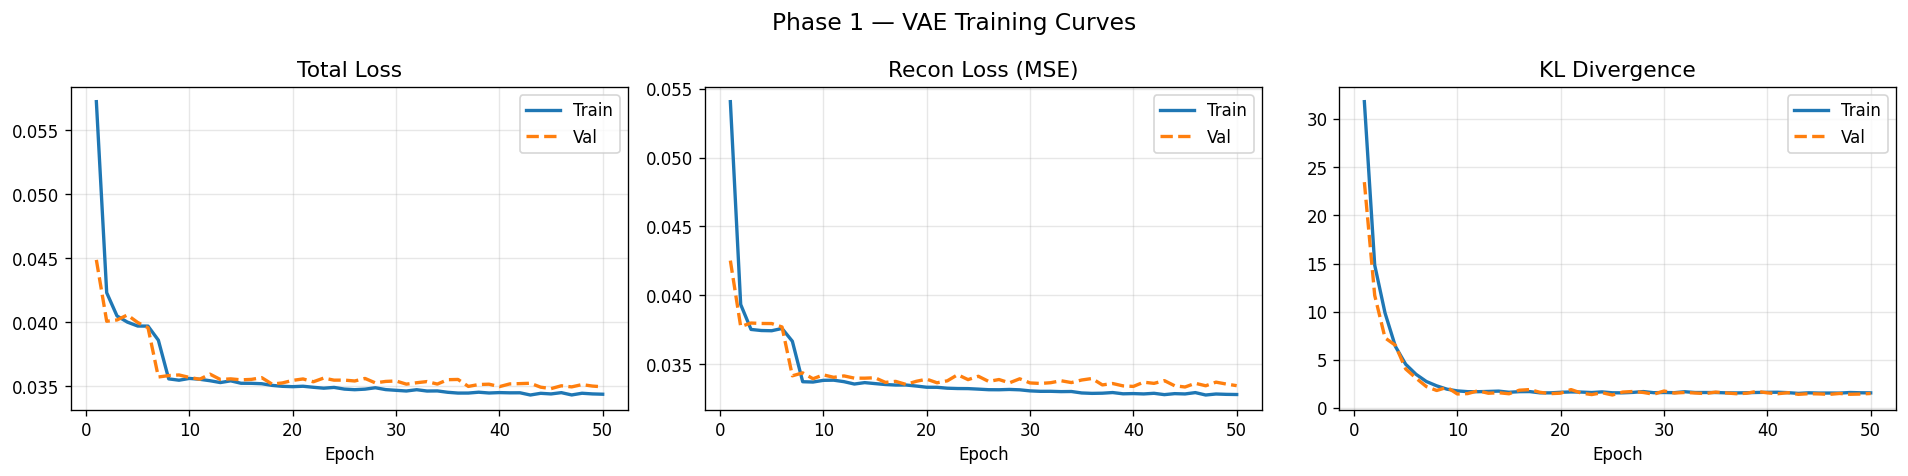

Training curves saved.


In [34]:
# ── Cell 8: Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
eps = range(1, len(history['train_total']) + 1)

pairs = [
    ('Total Loss',      'train_total', 'val_total'),
    ('Recon Loss (MSE)','train_recon', 'val_recon'),
    ('KL Divergence',   'train_kl',   'val_kl'),
]
for ax, (title, tk, vk) in zip(axes, pairs):
    ax.plot(eps, history[tk], label='Train', linewidth=2)
    ax.plot(eps, history[vk], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Phase 1 — VAE Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()
print('Training curves saved.')

In [35]:
# ── Cell 9: HiFi-GAN Vocoder (Phase 2) ───────────────────────────────────────
#  This is the generator-only (inference) version of HiFi-GAN.
#  Input : mel spectrogram (B, MEL_CHANNELS, T)
#  Output: waveform        (B, 1, T × 256)   at 22 050 Hz
#
#  Total upsampling factor: 8 × 8 × 2 × 2 = 256
#  (1292 frames × 256 = ~330 k samples ≈ 15 s at 22 050 Hz)
#
#  If a pre-trained checkpoint is not available the pipeline falls back
#  to the Griffin-Lim algorithm defined in Cell 10.
# ─────────────────────────────────────────────────────────────────────────────

class ResBlock1D(nn.Module):
    """HiFi-GAN multi-receptive-field residual block."""
    def __init__(self, channels, kernel_size=3, dilations=(1, 3, 5)):
        super().__init__()
        self.convs1 = nn.ModuleList([
            nn.utils.weight_norm(
                nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=d, padding=(kernel_size - 1) * d // 2)
            ) for d in dilations
        ])
        self.convs2 = nn.ModuleList([
            nn.utils.weight_norm(
                nn.Conv1d(channels, channels, kernel_size, 1,
                          dilation=1, padding=(kernel_size - 1) // 2)
            ) for _ in dilations
        ])

    def forward(self, x):
        for c1, c2 in zip(self.convs1, self.convs2):
            r = F.leaky_relu(x, 0.1)
            r = c1(r)
            r = F.leaky_relu(r, 0.1)
            r = c2(r)
            x = x + r
        return x


class HiFiGANGenerator(nn.Module):
    """
    HiFi-GAN Generator.
    Accepts mel spectrograms with `in_channels` frequency bins.
    Set in_channels=128 to match the CVAE output directly
    (no external projection needed).
    """
    def __init__(self, in_channels=128):
        super().__init__()
        self.pre = nn.utils.weight_norm(
            nn.Conv1d(in_channels, 512, 7, 1, padding=3)
        )
        up_rates   = [8, 8, 2, 2]
        up_kernels = [16, 16, 4, 4]
        res_kernels = [3, 7, 11]

        self.ups = nn.ModuleList()
        for i, (u, k) in enumerate(zip(up_rates, up_kernels)):
            ch_in  = 512 // (2 ** i)
            ch_out = ch_in // 2
            self.ups.append(nn.utils.weight_norm(
                nn.ConvTranspose1d(ch_in, ch_out, k, u,
                                   padding=(k - u) // 2)
            ))

        self.res_blocks = nn.ModuleList()
        for i in range(len(self.ups)):
            ch = 512 // (2 ** (i + 1))
            for rk in res_kernels:
                self.res_blocks.append(ResBlock1D(ch, rk))

        last_ch = 512 // (2 ** len(self.ups))
        self.post = nn.utils.weight_norm(
            nn.Conv1d(last_ch, 1, 7, 1, padding=3)
        )

    def forward(self, mel):
        """mel: (B, mel_ch, T) → waveform: (B, 1, T×256)"""
        x = self.pre(mel)
        for i, up in enumerate(self.ups):
            x  = F.leaky_relu(x, 0.1)
            x  = up(x)
            xs = None
            for j in range(3):
                b  = self.res_blocks[i * 3 + j](x)
                xs = b if xs is None else xs + b
            x = xs / 3.0
        return torch.tanh(self.post(F.leaky_relu(x, 0.1)))


print('HiFi-GAN Generator defined (accepts 128 mel channels natively).')

HiFi-GAN Generator defined (accepts 128 mel channels natively).


In [36]:
# ── Cell 10: Phase-2 Audio Generation ────────────────────────────────────────

# ── Griffin-Lim fallback vocoder ─────────────────────────────────────────────
def mel_to_audio_griffinlim(mel_norm, sr=22050, n_fft=1024,
                              hop=256, n_iter=64, fmin=0, fmax=8000):
    """
    Convert a normalised mel spectrogram (values in [-1, 1]) to audio
    using the Griffin-Lim algorithm.  This is the fallback when no
    HiFi-GAN checkpoint is available.

    Steps:
        1. Denormalise [-1,1] back to approximate dB range
        2. dB → power
        3. Griffin-Lim inverse mel transform
    """
    # Approximate inverse of z-score + clip normalisation used in the Dataset
    mel_db    = mel_norm * 80.0 - 10.0       # rough dB scale recovery
    mel_power = librosa.db_to_power(mel_db)
    audio     = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr         = sr,
        n_fft      = n_fft,
        hop_length = hop,
        n_iter     = n_iter,
        fmin       = fmin,
        fmax       = fmax,
    )
    return audio.astype(np.float32)


# ── Main generation function ──────────────────────────────────────────────────
def generate_audio(target_genre,
                   num_samples    = 1,
                   temperature    = 1.0,
                   use_hifigan    = False,
                   hifigan_ckpt   = None,
                   output_dir     = None):
    """
    Phase-2 generation pipeline:
        1. Sample z ~ N(0, temperature²·I)
        2. Optionally concatenate genre embedding   (diagram conditioning box)
        3. Decode through CNN Decoder → Synthesised Mel Spectrogram
        4. Vocode to .wav via Griffin-Lim OR HiFi-GAN

    Args:
        target_genre   : one of the 6 genre strings
        num_samples    : how many independent .wav files to generate
        temperature    : controls diversity (>1 → more diverse, <1 → more conservative)
        use_hifigan    : True to attempt HiFi-GAN vocoding
        hifigan_ckpt   : path to pre-trained HiFi-GAN checkpoint (.pth)
        output_dir     : directory to save .wav files (default: config.OUTPUT_DIR)

    Returns list of saved file paths.
    """
    assert target_genre in genre_to_idx, \
        f"Unknown genre '{target_genre}'. Choose from: {list(genre_to_idx.keys())}"

    if output_dir is None:
        output_dir = config.OUTPUT_DIR
    os.makedirs(output_dir, exist_ok=True)

    # Load best checkpoint
    best_ckpt_path = os.path.join(config.CHECKPOINT_DIR, 'cvae_best.pth')
    if os.path.exists(best_ckpt_path):
        state = torch.load(best_ckpt_path, map_location=config.DEVICE)
        cvae.load_state_dict(state['model'])
        print(f'Loaded best model from epoch {state["epoch"]} '
              f'(val_loss={state["val_loss"]:.5f})')
    cvae.eval()

    # Optional HiFi-GAN setup
    vocoder = None
    if use_hifigan:
        ckpt_path = hifigan_ckpt or config.HIFIGAN_CKPT
        if ckpt_path and os.path.exists(ckpt_path):
            vocoder = HiFiGANGenerator(in_channels=config.MEL_CHANNELS)\
                        .to(config.DEVICE).eval()
            sd  = torch.load(ckpt_path, map_location=config.DEVICE)
            key = 'generator' if 'generator' in sd else None
            vocoder.load_state_dict(sd[key] if key else sd)
            print(f'HiFi-GAN loaded from {ckpt_path}')
        else:
            print('[WARN] HiFi-GAN checkpoint not found — using Griffin-Lim.')

    saved = []
    label_t = torch.tensor([genre_to_idx[target_genre]],
                            dtype=torch.long, device=config.DEVICE)

    for i in range(num_samples):
        with torch.no_grad():
            # Step 1-3: sample z, condition on genre, decode
            z       = torch.randn(1, config.LATENT_DIM,
                                  device=config.DEVICE) * temperature
            mel_gen = cvae.decoder(z, label_t)            # (1, 1, 128, 1292)
            mel_np  = mel_gen.squeeze().cpu().numpy()      # (128, 1292)

            # Step 4: vocode
            if vocoder is not None:
                # HiFi-GAN path: feed (1, 128, T) directly
                wave  = vocoder(mel_gen.squeeze(0))        # (1, 1, T*256)
                audio = wave.squeeze().cpu().numpy()
            else:
                # Griffin-Lim path (default)
                audio = mel_to_audio_griffinlim(
                    mel_np,
                    sr     = config.SAMPLE_RATE,
                    n_fft  = config.N_FFT,
                    hop    = config.HOP_LENGTH,
                    n_iter = config.GRIFFIN_ITER,
                )

        # Normalise peak to 95 % FS
        peak = np.abs(audio).max()
        if peak > 0:
            audio = audio / peak * 0.95

        out_path = os.path.join(output_dir,
                                f'generated_{target_genre}_{i+1:02d}.wav')
        sf.write(out_path, audio, config.SAMPLE_RATE)
        saved.append(out_path)
        print(f'  [✔] {out_path}')

    return saved


# ── Generate one .wav per genre ───────────────────────────────────────────────
print('=' * 65)
print('  Phase 2: Generating Synthetic Audio')
print('=' * 65)

all_generated = {}
for genre in config.GENRES:
    print(f'\n── {genre} ──')
    paths = generate_audio(
        genre,
        num_samples  = 2,          # 2 variations per genre
        temperature  = 1.0,
        use_hifigan  = False,      # set True + provide hifigan_ckpt if available
    )
    all_generated[genre] = paths

print(f'\n✓ Generated {sum(len(v) for v in all_generated.values())} audio files.')

  Phase 2: Generating Synthetic Audio

── bhajan ──
Loaded best model from epoch 45 (val_loss=0.03481)
  [✔] /kaggle/working/generated_bhajan_01.wav
  [✔] /kaggle/working/generated_bhajan_02.wav

── deuda ──
Loaded best model from epoch 45 (val_loss=0.03481)
  [✔] /kaggle/working/generated_deuda_01.wav
  [✔] /kaggle/working/generated_deuda_02.wav

── lok_dohori ──
Loaded best model from epoch 45 (val_loss=0.03481)
  [✔] /kaggle/working/generated_lok_dohori_01.wav
  [✔] /kaggle/working/generated_lok_dohori_02.wav

── newari ──
Loaded best model from epoch 45 (val_loss=0.03481)
  [✔] /kaggle/working/generated_newari_01.wav
  [✔] /kaggle/working/generated_newari_02.wav

── tamang_selo ──
Loaded best model from epoch 45 (val_loss=0.03481)
  [✔] /kaggle/working/generated_tamang_selo_01.wav
  [✔] /kaggle/working/generated_tamang_selo_02.wav

── tharu ──
Loaded best model from epoch 45 (val_loss=0.03481)
  [✔] /kaggle/working/generated_tharu_01.wav
  [✔] /kaggle/working/generated_tharu_02.wav

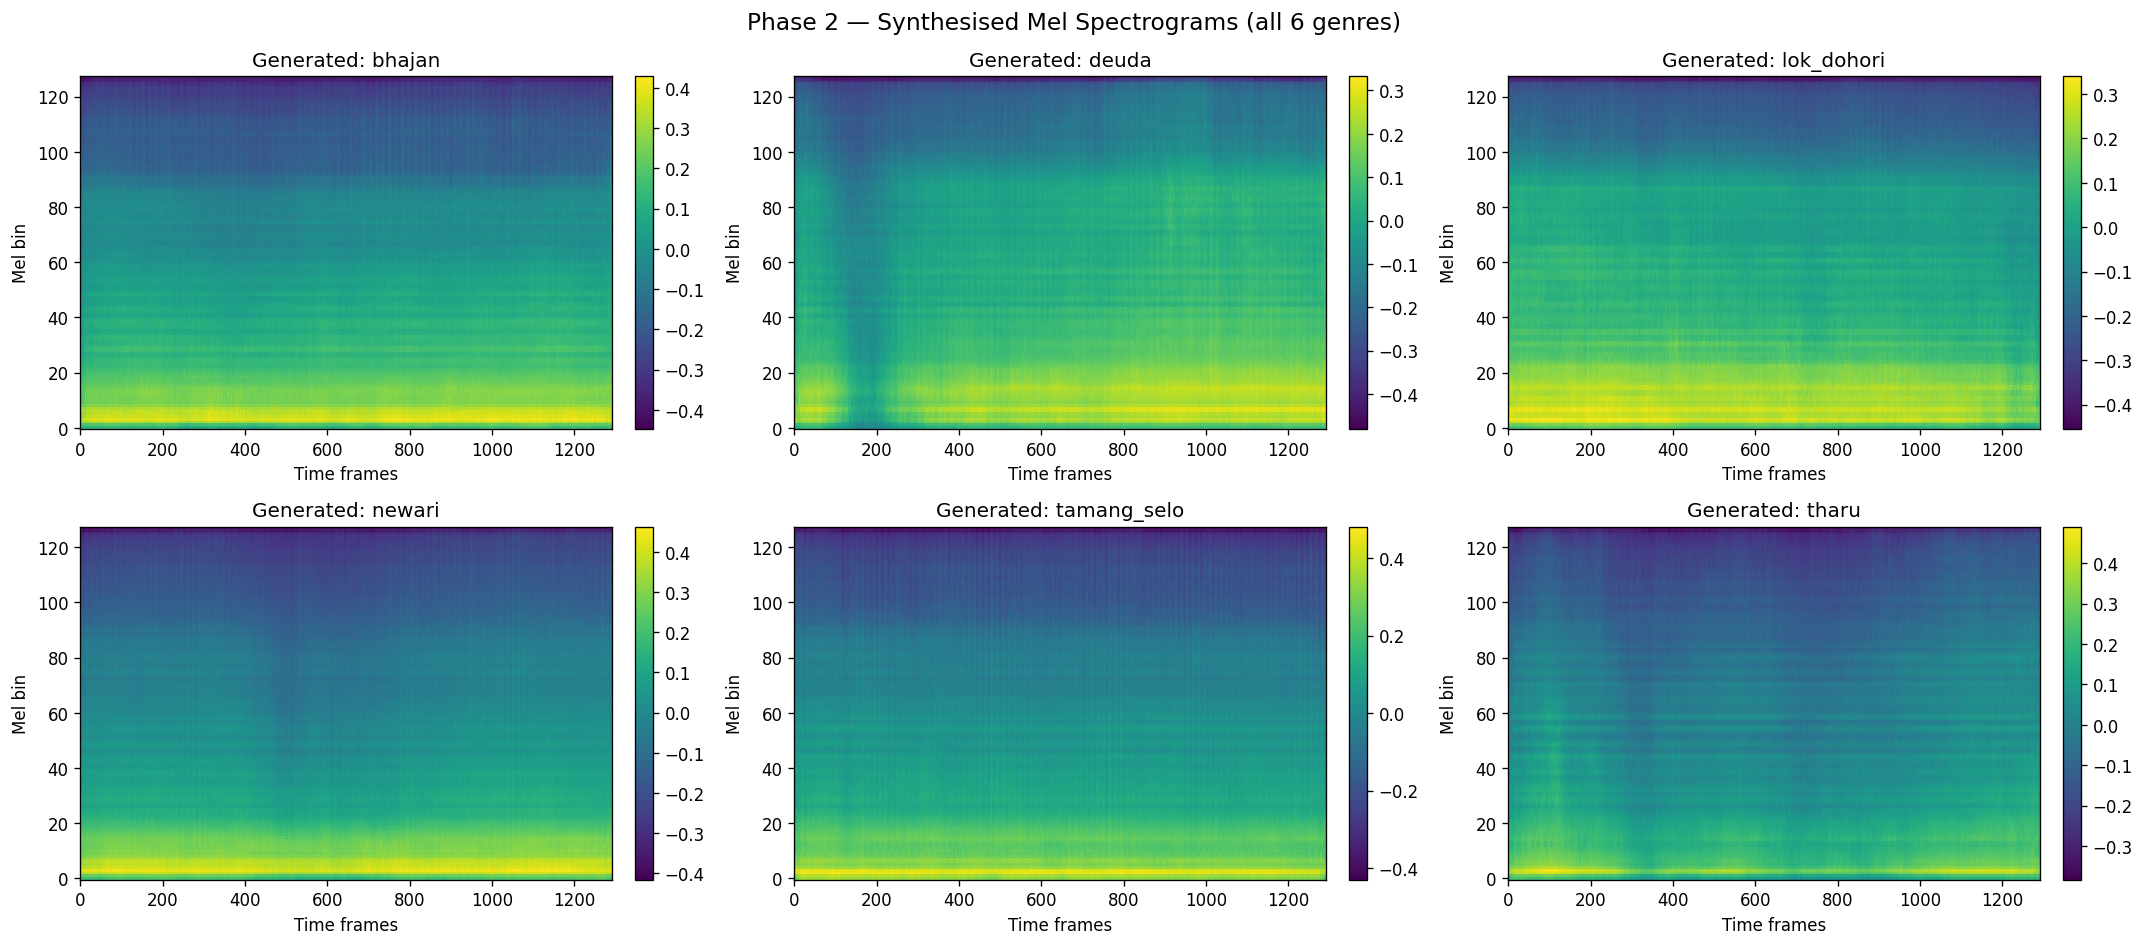

Spectrogram visualisation saved.


In [37]:
# ── Cell 11: Visualise Generated Mel Spectrograms (all 6 genres) ──────────────
cvae.eval()
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for idx, genre in enumerate(config.GENRES):
    label_t = torch.tensor([genre_to_idx[genre]],
                            dtype=torch.long, device=config.DEVICE)
    with torch.no_grad():
        z   = torch.randn(1, config.LATENT_DIM, device=config.DEVICE)
        mel = cvae.decoder(z, label_t).squeeze().cpu().numpy()   # (128, 1292)

    im = axes[idx].imshow(mel, aspect='auto', origin='lower',
                           cmap='viridis', interpolation='nearest')
    axes[idx].set_title(f'Generated: {genre}', fontsize=12)
    axes[idx].set_xlabel('Time frames')
    axes[idx].set_ylabel('Mel bin')
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

plt.suptitle('Phase 2 — Synthesised Mel Spectrograms (all 6 genres)',
             fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'generated_spectrograms.png'),
            dpi=150)
plt.show()
print('Spectrogram visualisation saved.')

Sample 1 (lok_dohori): MSE = 0.034164
Sample 2 (newari): MSE = 0.028404
Sample 3 (tamang_selo): MSE = 0.039072


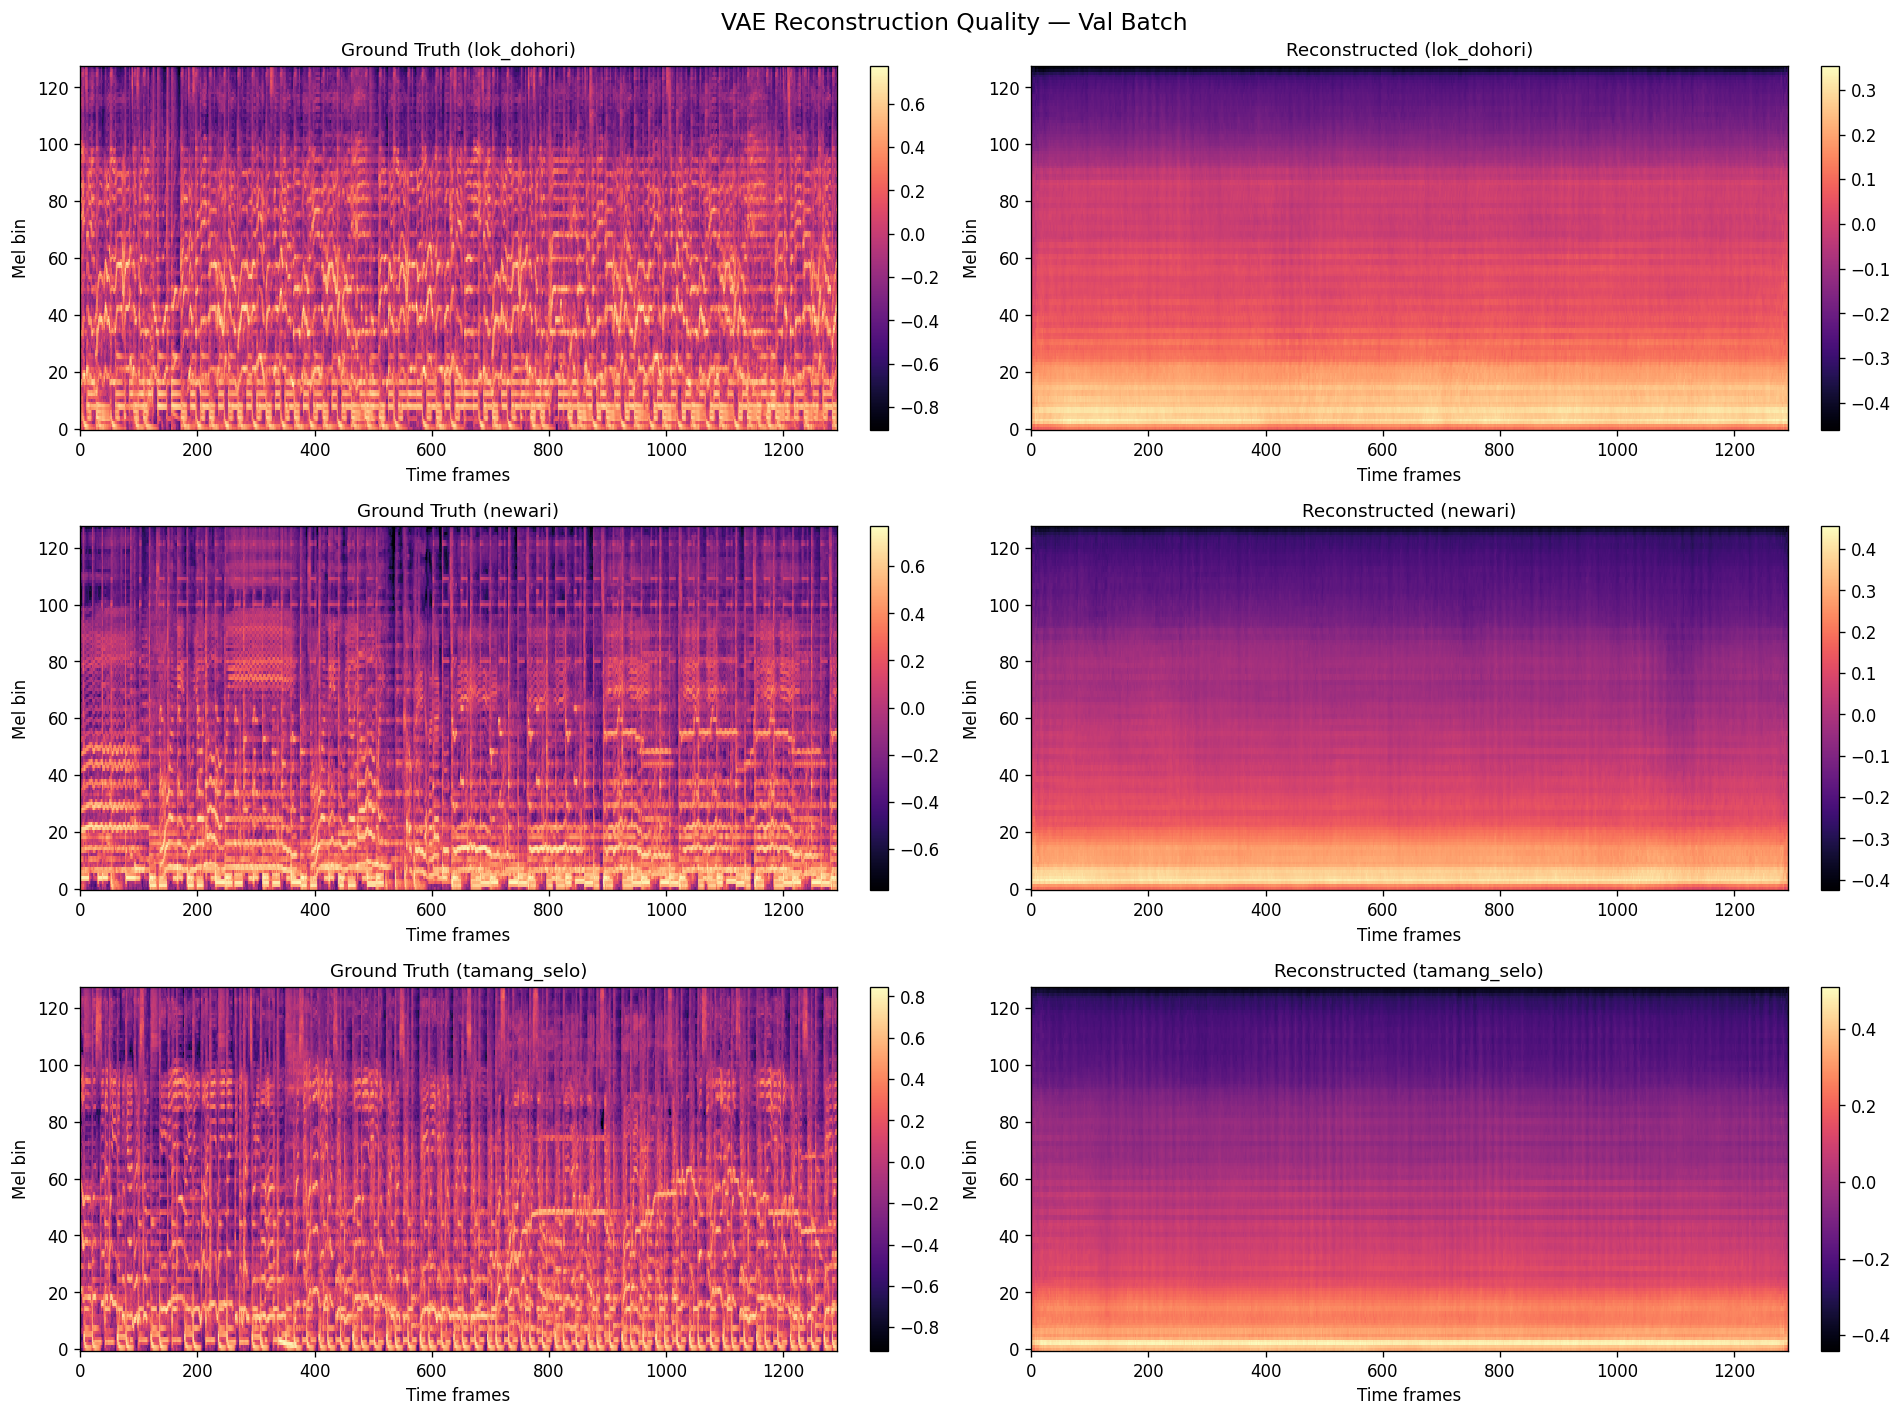

In [38]:
# ── Cell 12: Reconstruction Quality Check (Ground-Truth vs Reconstructed) ─────
#  Feed a real spectrogram through the encoder + decoder and compare side-by-side.

cvae.eval()
sample_mel, sample_lbl = next(iter(val_loader))
sample_mel = sample_mel.to(config.DEVICE)
sample_lbl = sample_lbl.to(config.DEVICE)

with torch.no_grad():
    recon, mu, logvar = cvae(sample_mel, sample_lbl)

n_show = min(3, sample_mel.shape[0])
fig, axes = plt.subplots(n_show, 2, figsize=(16, 4 * n_show))
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    gt  = sample_mel[i].squeeze().cpu().numpy()   # (128, 1292)
    rec = recon[i].squeeze().cpu().numpy()
    genre_name = idx_to_genre[sample_lbl[i].item()]

    for ax, data, title in zip(axes[i], [gt, rec],
                                [f'Ground Truth ({genre_name})',
                                 f'Reconstructed ({genre_name})']):
        im = ax.imshow(data, aspect='auto', origin='lower',
                       cmap='magma', interpolation='nearest')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Time frames')
        ax.set_ylabel('Mel bin')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    mse = float(F.mse_loss(recon[i], sample_mel[i]).item())
    print(f'Sample {i+1} ({genre_name}): MSE = {mse:.6f}')

plt.suptitle('VAE Reconstruction Quality — Val Batch', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'reconstruction_check.png'), dpi=150)
plt.show()